In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


# Install Libraries

In [ ]:
# !pip install ultralytics==8.2.103 -q
# !pip install roboflow==1.1.48 --quiet

# Libraries

In [19]:
from IPython import display
display.clear_output()
from ultralytics import YOLO
from IPython.display import display, Image
import ultralytics
ultralytics.checks()
from roboflow import Roboflow

Ultralytics YOLOv8.2.103 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.7/112.6 GB disk)


# Import Datasets

In [ ]:
# Bigger model dataset import
# !mkdir -p {HOME}/datasets
%cd {HOME}/datasets
rf = Roboflow(api_key="")
project = rf.workspace("chicken-disease").project("disease-prediction-oryuo")
version = project.version(2)
dataset = version.download("yolov8")

/content/datasets
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.4 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Disease-Prediction-2 in yolov8:: 100%|██████████| 412/412 [00:00<00:00, 6916.22it/s]


In [21]:
# Smaller model dataset import
rf1 = Roboflow(api_key="ecLd6CP6UIRA2wXaKRAl")
project1 = rf1.workspace("obinson-tobinson").project("hendiseasedetection-octdy")
version1 = project1.version(1)
dataset1 = version1.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to HenDiseaseDetection-1 in yolov8:: 100%|██████████| 627/627 [00:00<00:00, 7554.87it/s]


# Bigger Model

## Custom Training

In [8]:
%cd {HOME}

!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml epochs=30 imgsz=800 plots=True

/content
New https://pypi.org/project/ultralytics/8.3.94 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/datasets/Disease-Prediction-2/data.yaml, epochs=30, time=None, patience=100, batch=16, imgsz=800, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False

## Visualising Results

/content


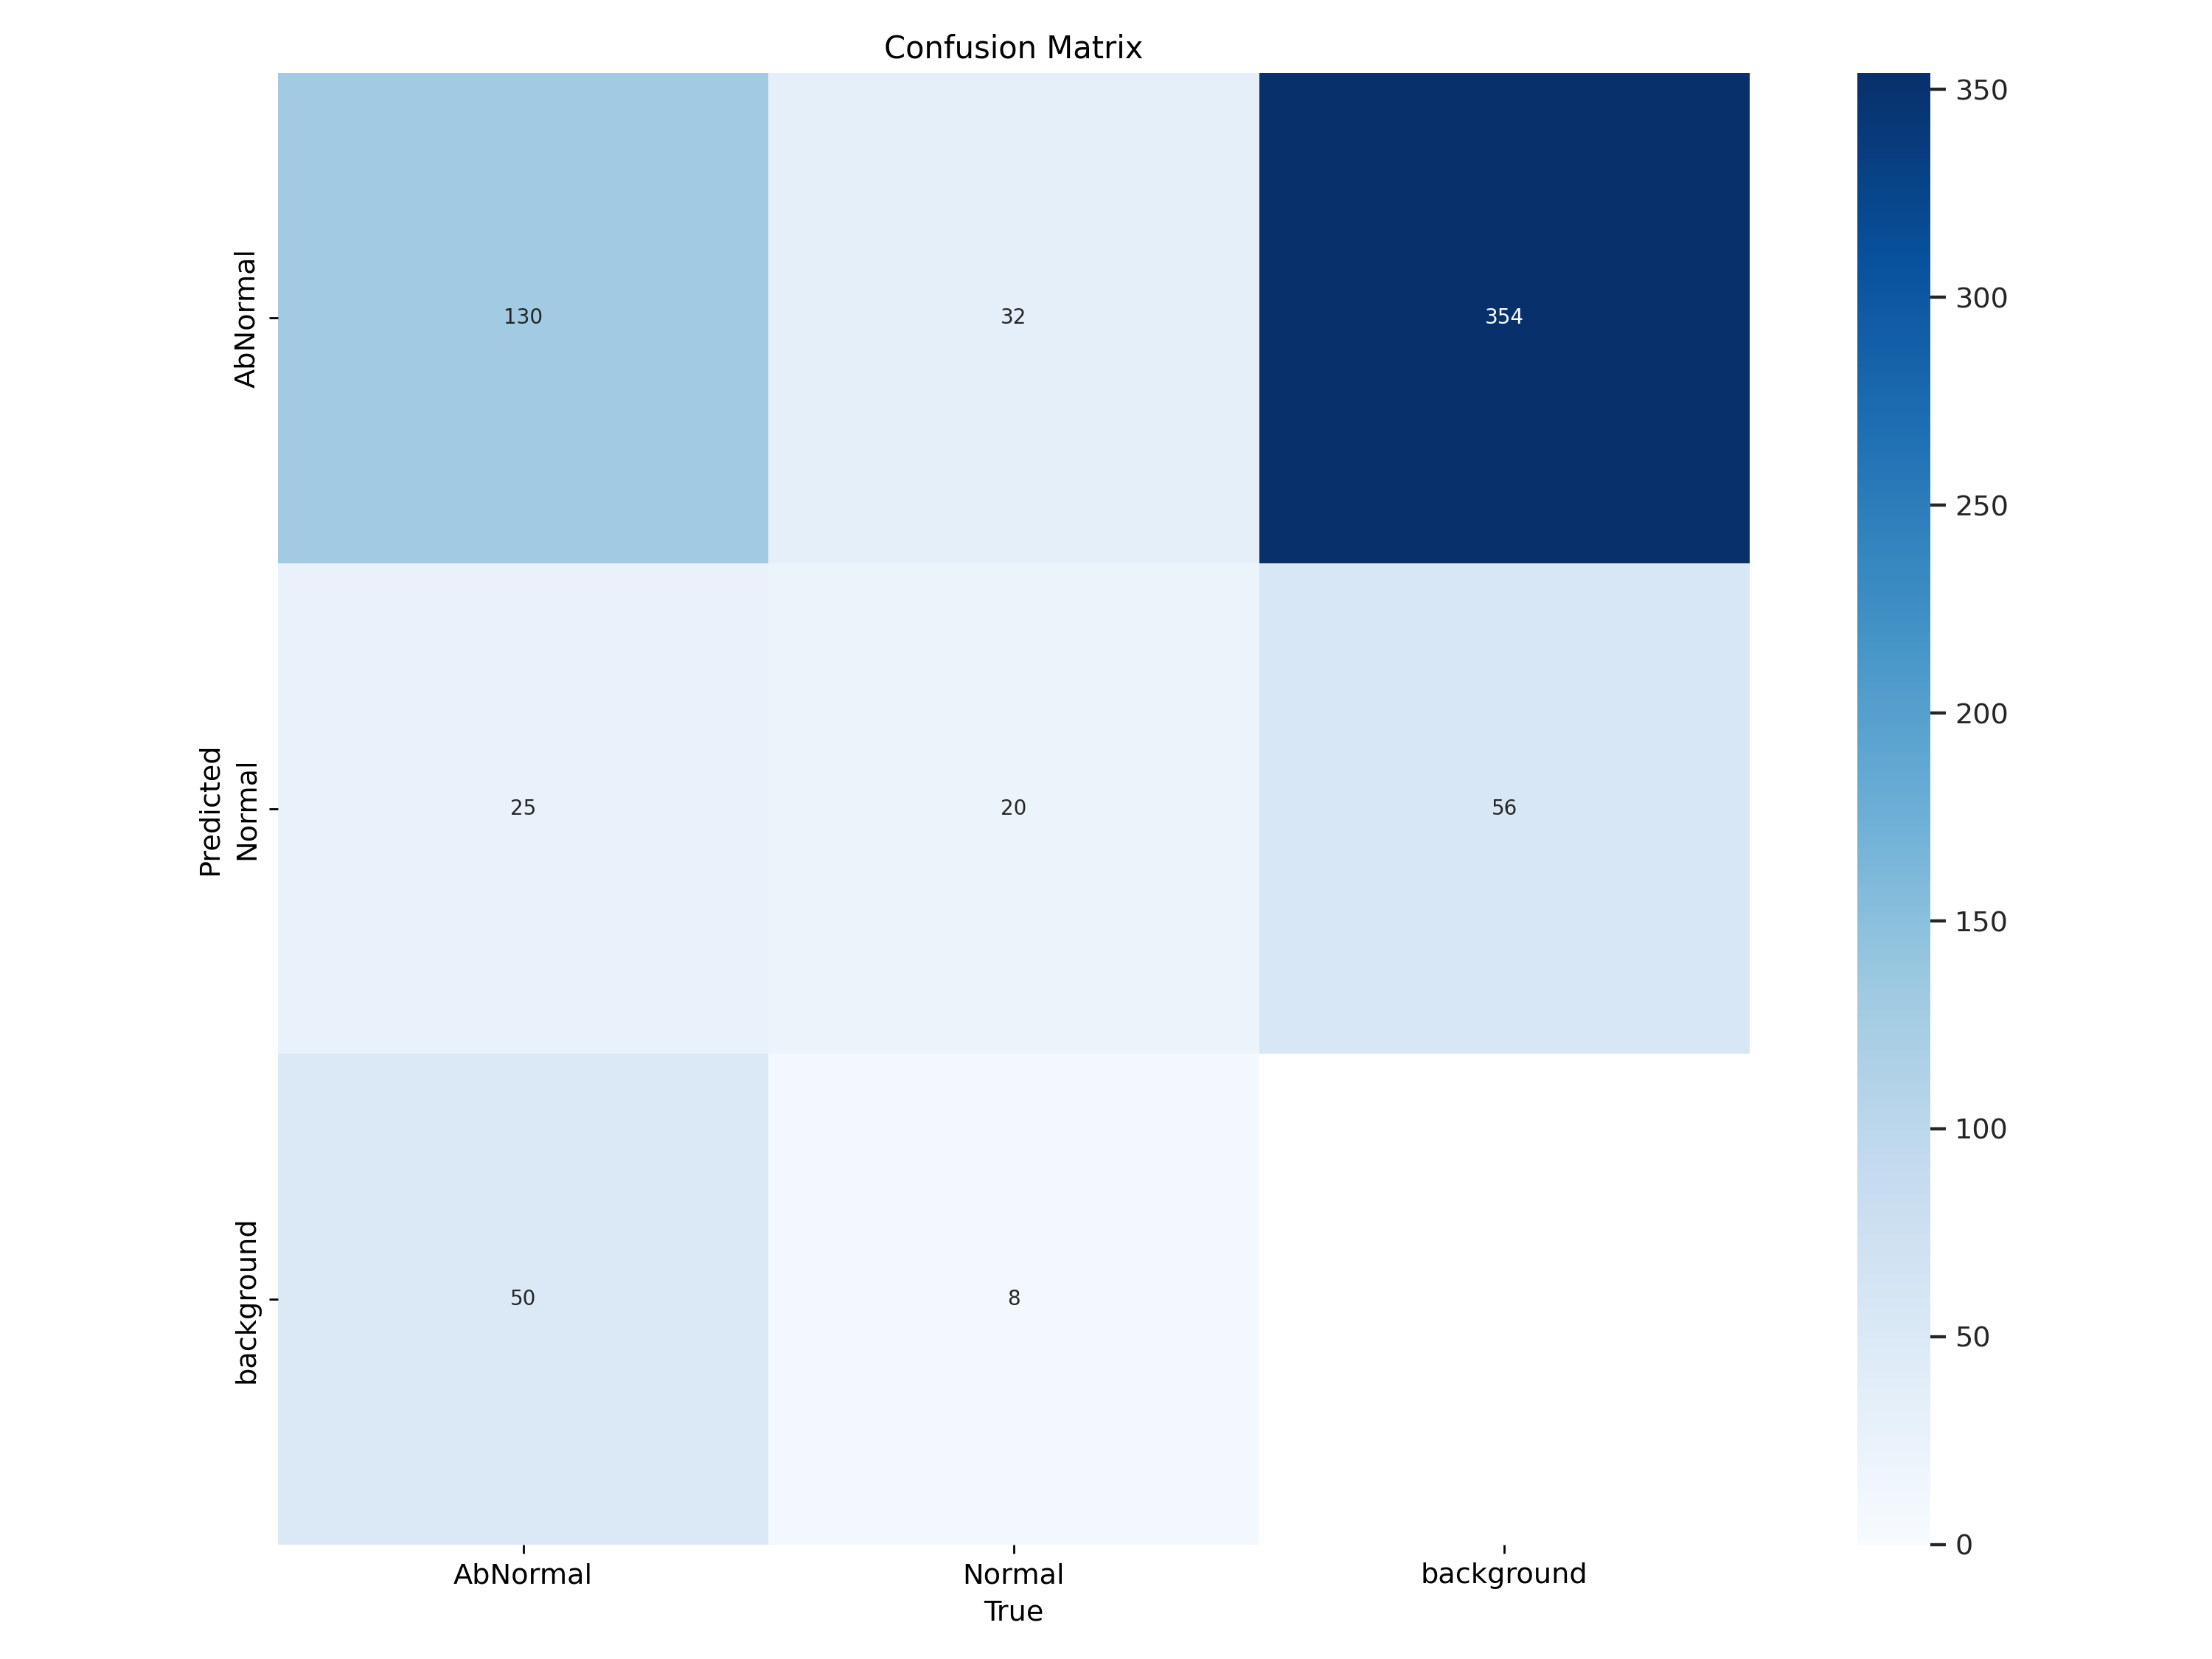

In [9]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

/content


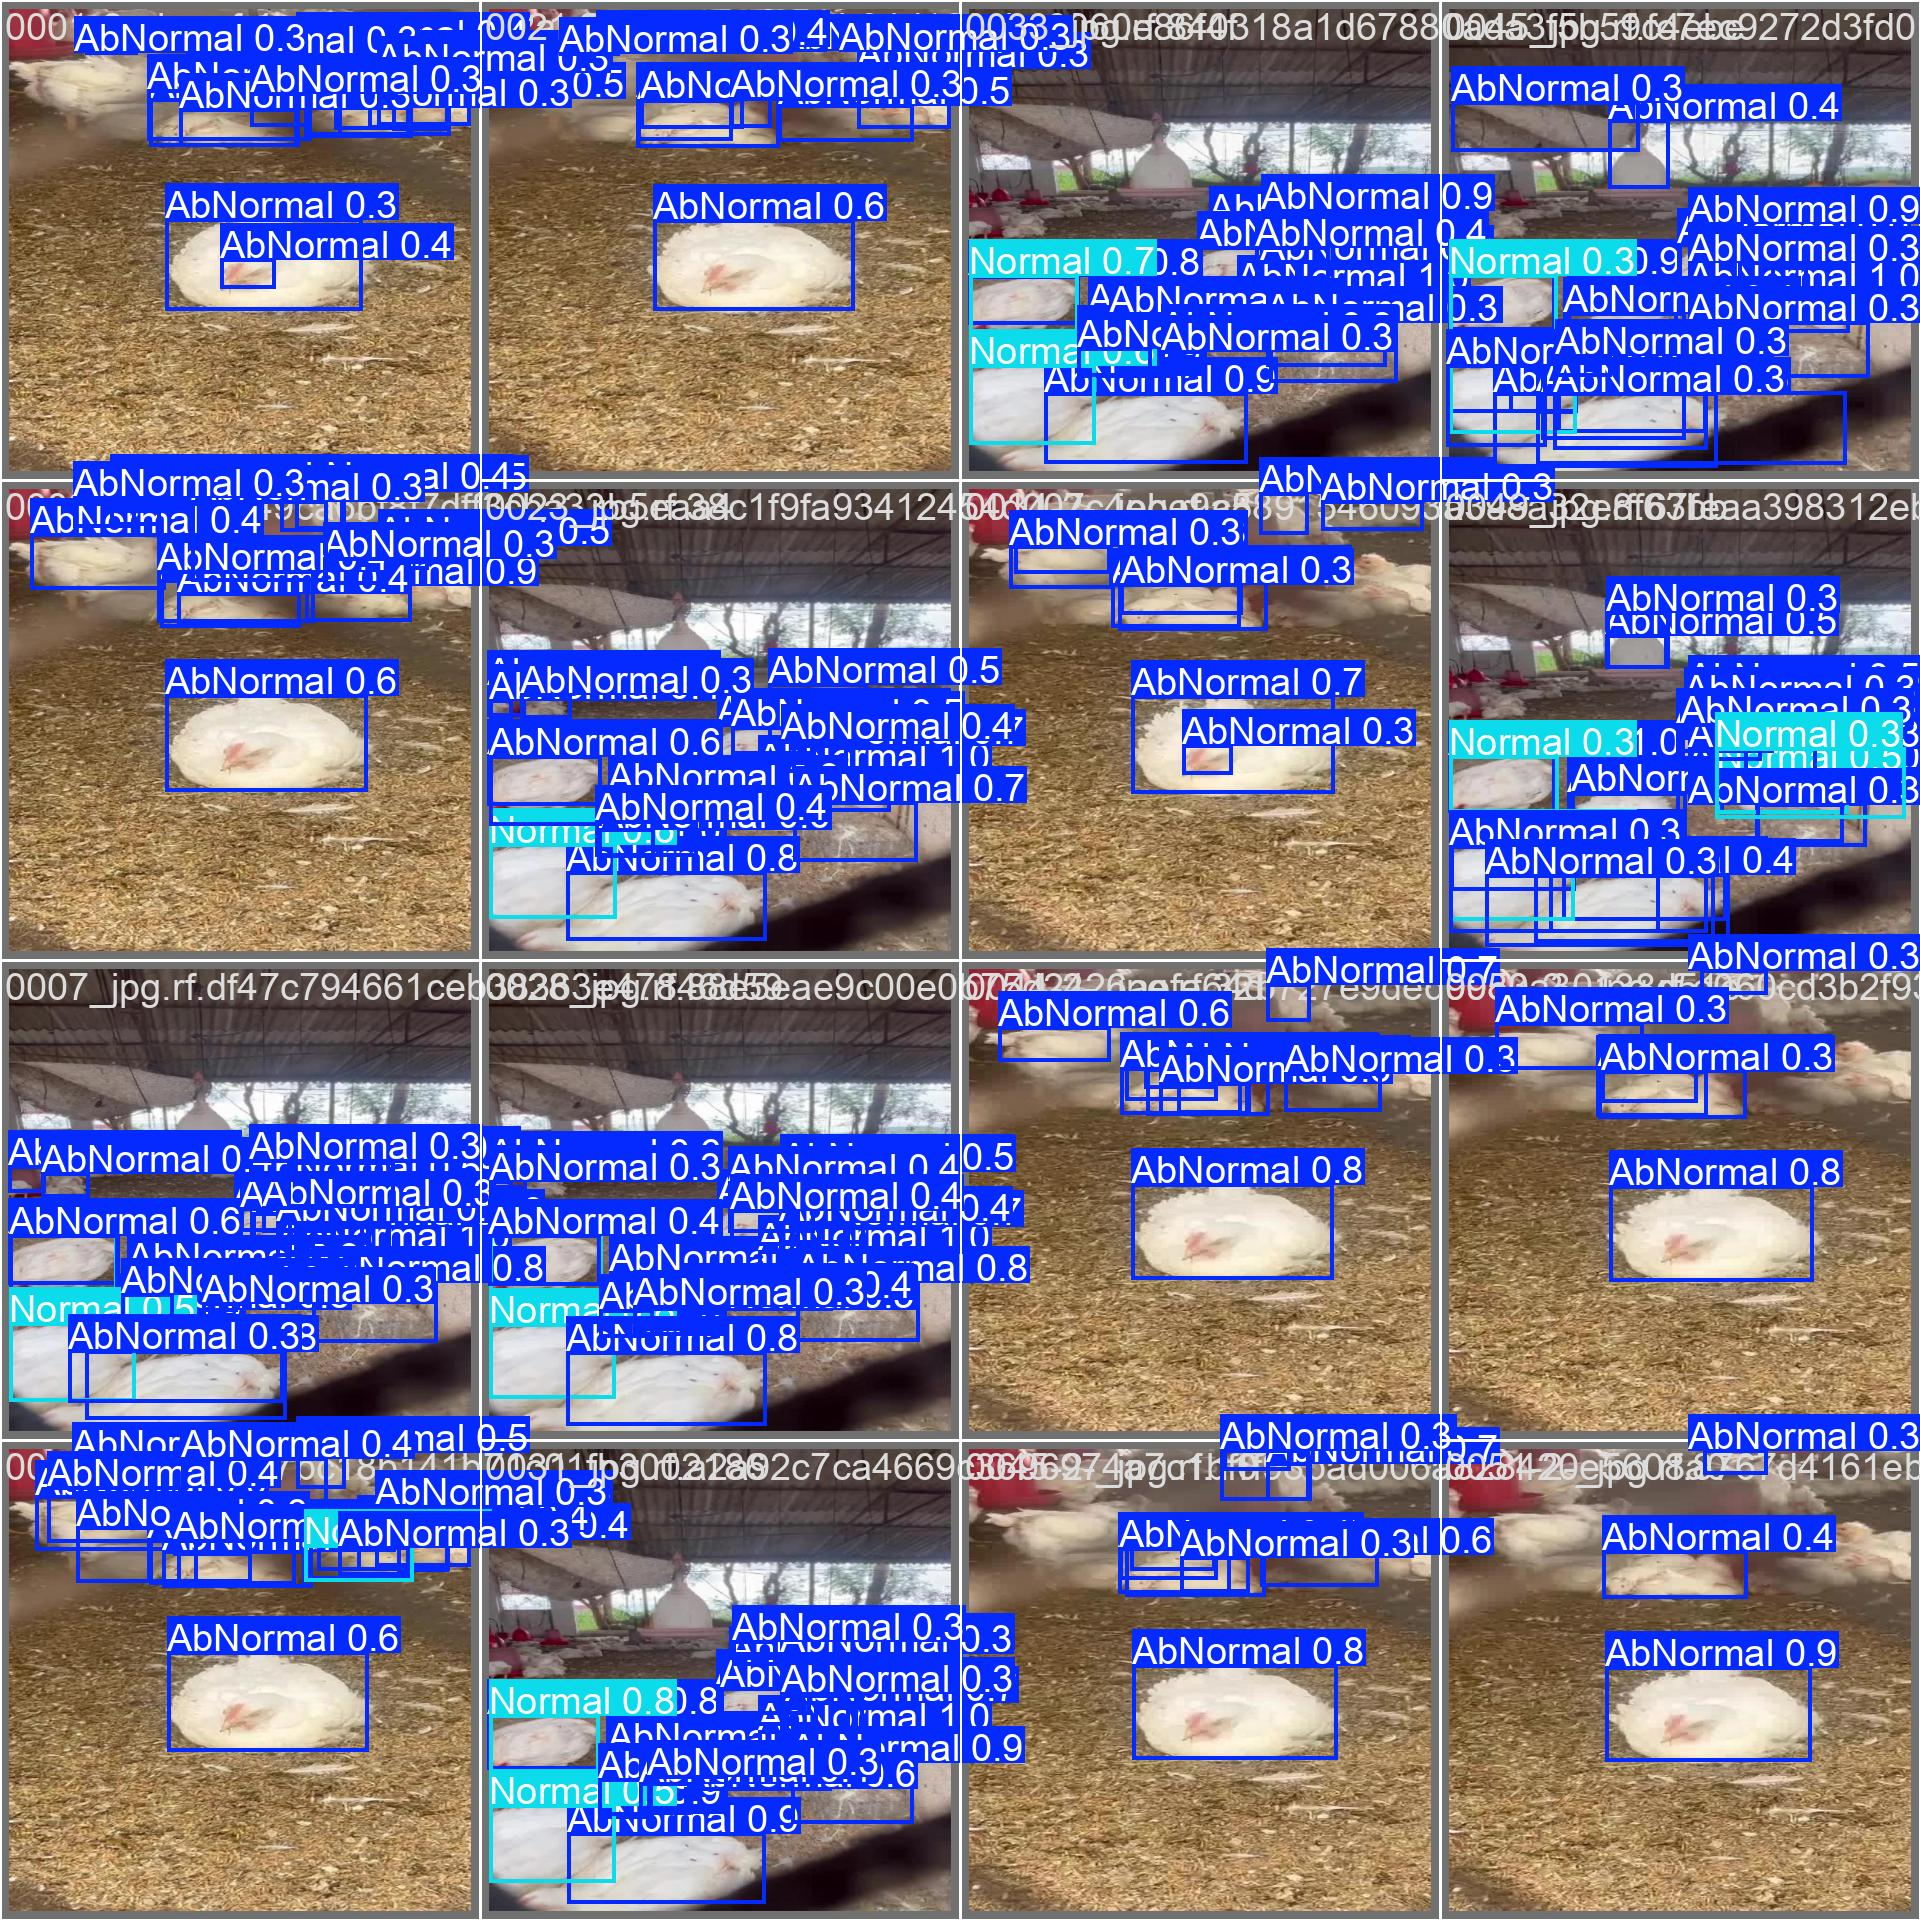

In [20]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

## Validate Custom Model

In [12]:
%cd {HOME}
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

/content
Ultralytics YOLOv8.2.103 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 168 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Scanning /content/datasets/Disease-Prediction-2/valid/labels.cache... 40 images, 0 backgrounds, 0 corrupt: 100% 40/40 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 3/3 [00:02<00:00,  1.18it/s]
                   all         40        265      0.632      0.481      0.512      0.268
              AbNormal         40        205      0.605      0.595      0.563      0.309
                Normal         28         60      0.659      0.367      0.461      0.227
Speed: 0.5ms preprocess, 24.2ms inference, 0.0ms loss, 15.8ms postprocess per image
Results saved to runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


## Inference with Custom Model

In [16]:
%cd {HOME}
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.60 source={dataset.location}/test/images save=True

/content
Ultralytics YOLOv8.2.103 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 168 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs

image 1/20 /content/datasets/Disease-Prediction-2/test/images/0010_jpg.rf.f88f45f64698545b7b0de9f3d86c8cfd.jpg: 800x800 12 AbNormals, 1 Normal, 22.8ms
image 2/20 /content/datasets/Disease-Prediction-2/test/images/0018-2-_jpg.rf.5a1b8d0c80db5883c677b0de65d90971.jpg: 800x800 3 AbNormals, 22.9ms
image 3/20 /content/datasets/Disease-Prediction-2/test/images/0029-2-_jpg.rf.131d5c78d2cd2c5f9c73512b30aff5ef.jpg: 800x800 6 AbNormals, 22.9ms
image 4/20 /content/datasets/Disease-Prediction-2/test/images/0031-2-_jpg.rf.1425197455d319bf5f4231b8029c3092.jpg: 800x800 7 AbNormals, 22.8ms
image 5/20 /content/datasets/Disease-Prediction-2/test/images/0035_jpg.rf.c0235edc3c33a59d30a5f54a044dca6d.jpg: 800x800 9 AbNormals, 1 Normal, 22.8ms
image 6/20 /content/datasets/Disease-Prediction-2/test/images/0038_jpg.rf.8957ae8b881c210

**NOTE:** Let's take a look at few results.

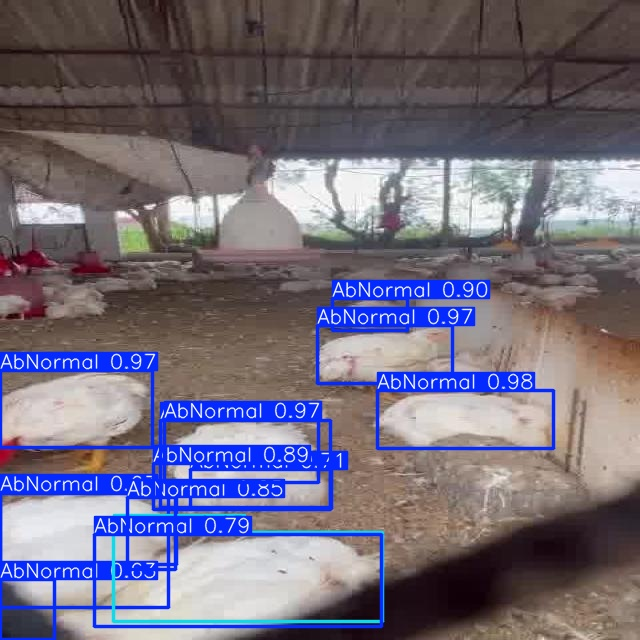

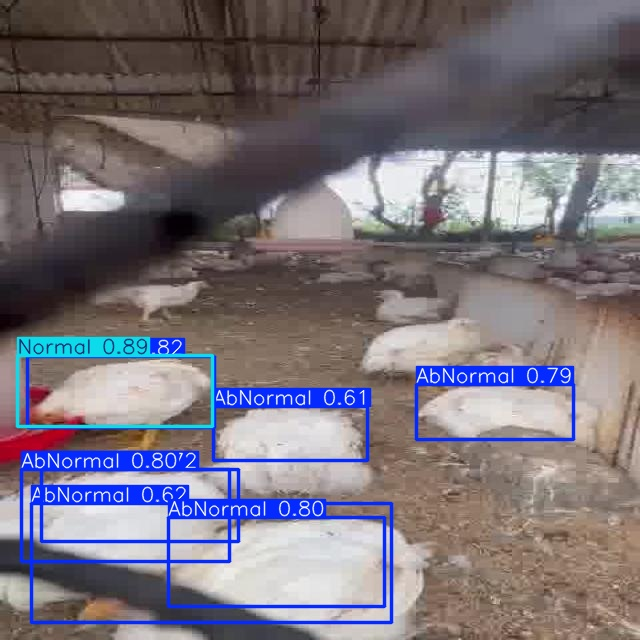

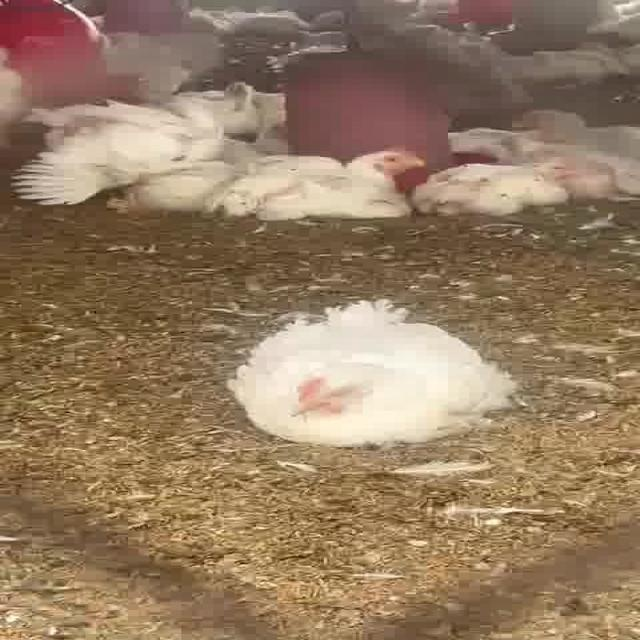

In [17]:
import glob
from IPython.display import Image, display

# Define the base path where the folders are located
base_path = '/content/runs/detect/'

# List all directories that start with 'predict' in the base path
subfolders = [os.path.join(base_path, d) for d in os.listdir(base_path)
              if os.path.isdir(os.path.join(base_path, d)) and d.startswith('predict')]

# Find the latest folder by modification time
latest_folder = max(subfolders, key=os.path.getmtime)

image_paths = glob.glob(f'{latest_folder}/*.jpg')[:3]

# Display each image
for image_path in image_paths:
    display(Image(filename=image_path, width=600))
    print("\n")

# Smaller Model

## Custom Training

In [22]:
%cd {HOME}

!yolo task=detect mode=train model=yolov8s.pt data={dataset1.location}/data.yaml epochs=10 imgsz=800 plots=True

/content
New https://pypi.org/project/ultralytics/8.3.94 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/HenDiseaseDetection-1/data.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=800, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=

## Visualising Results

/content


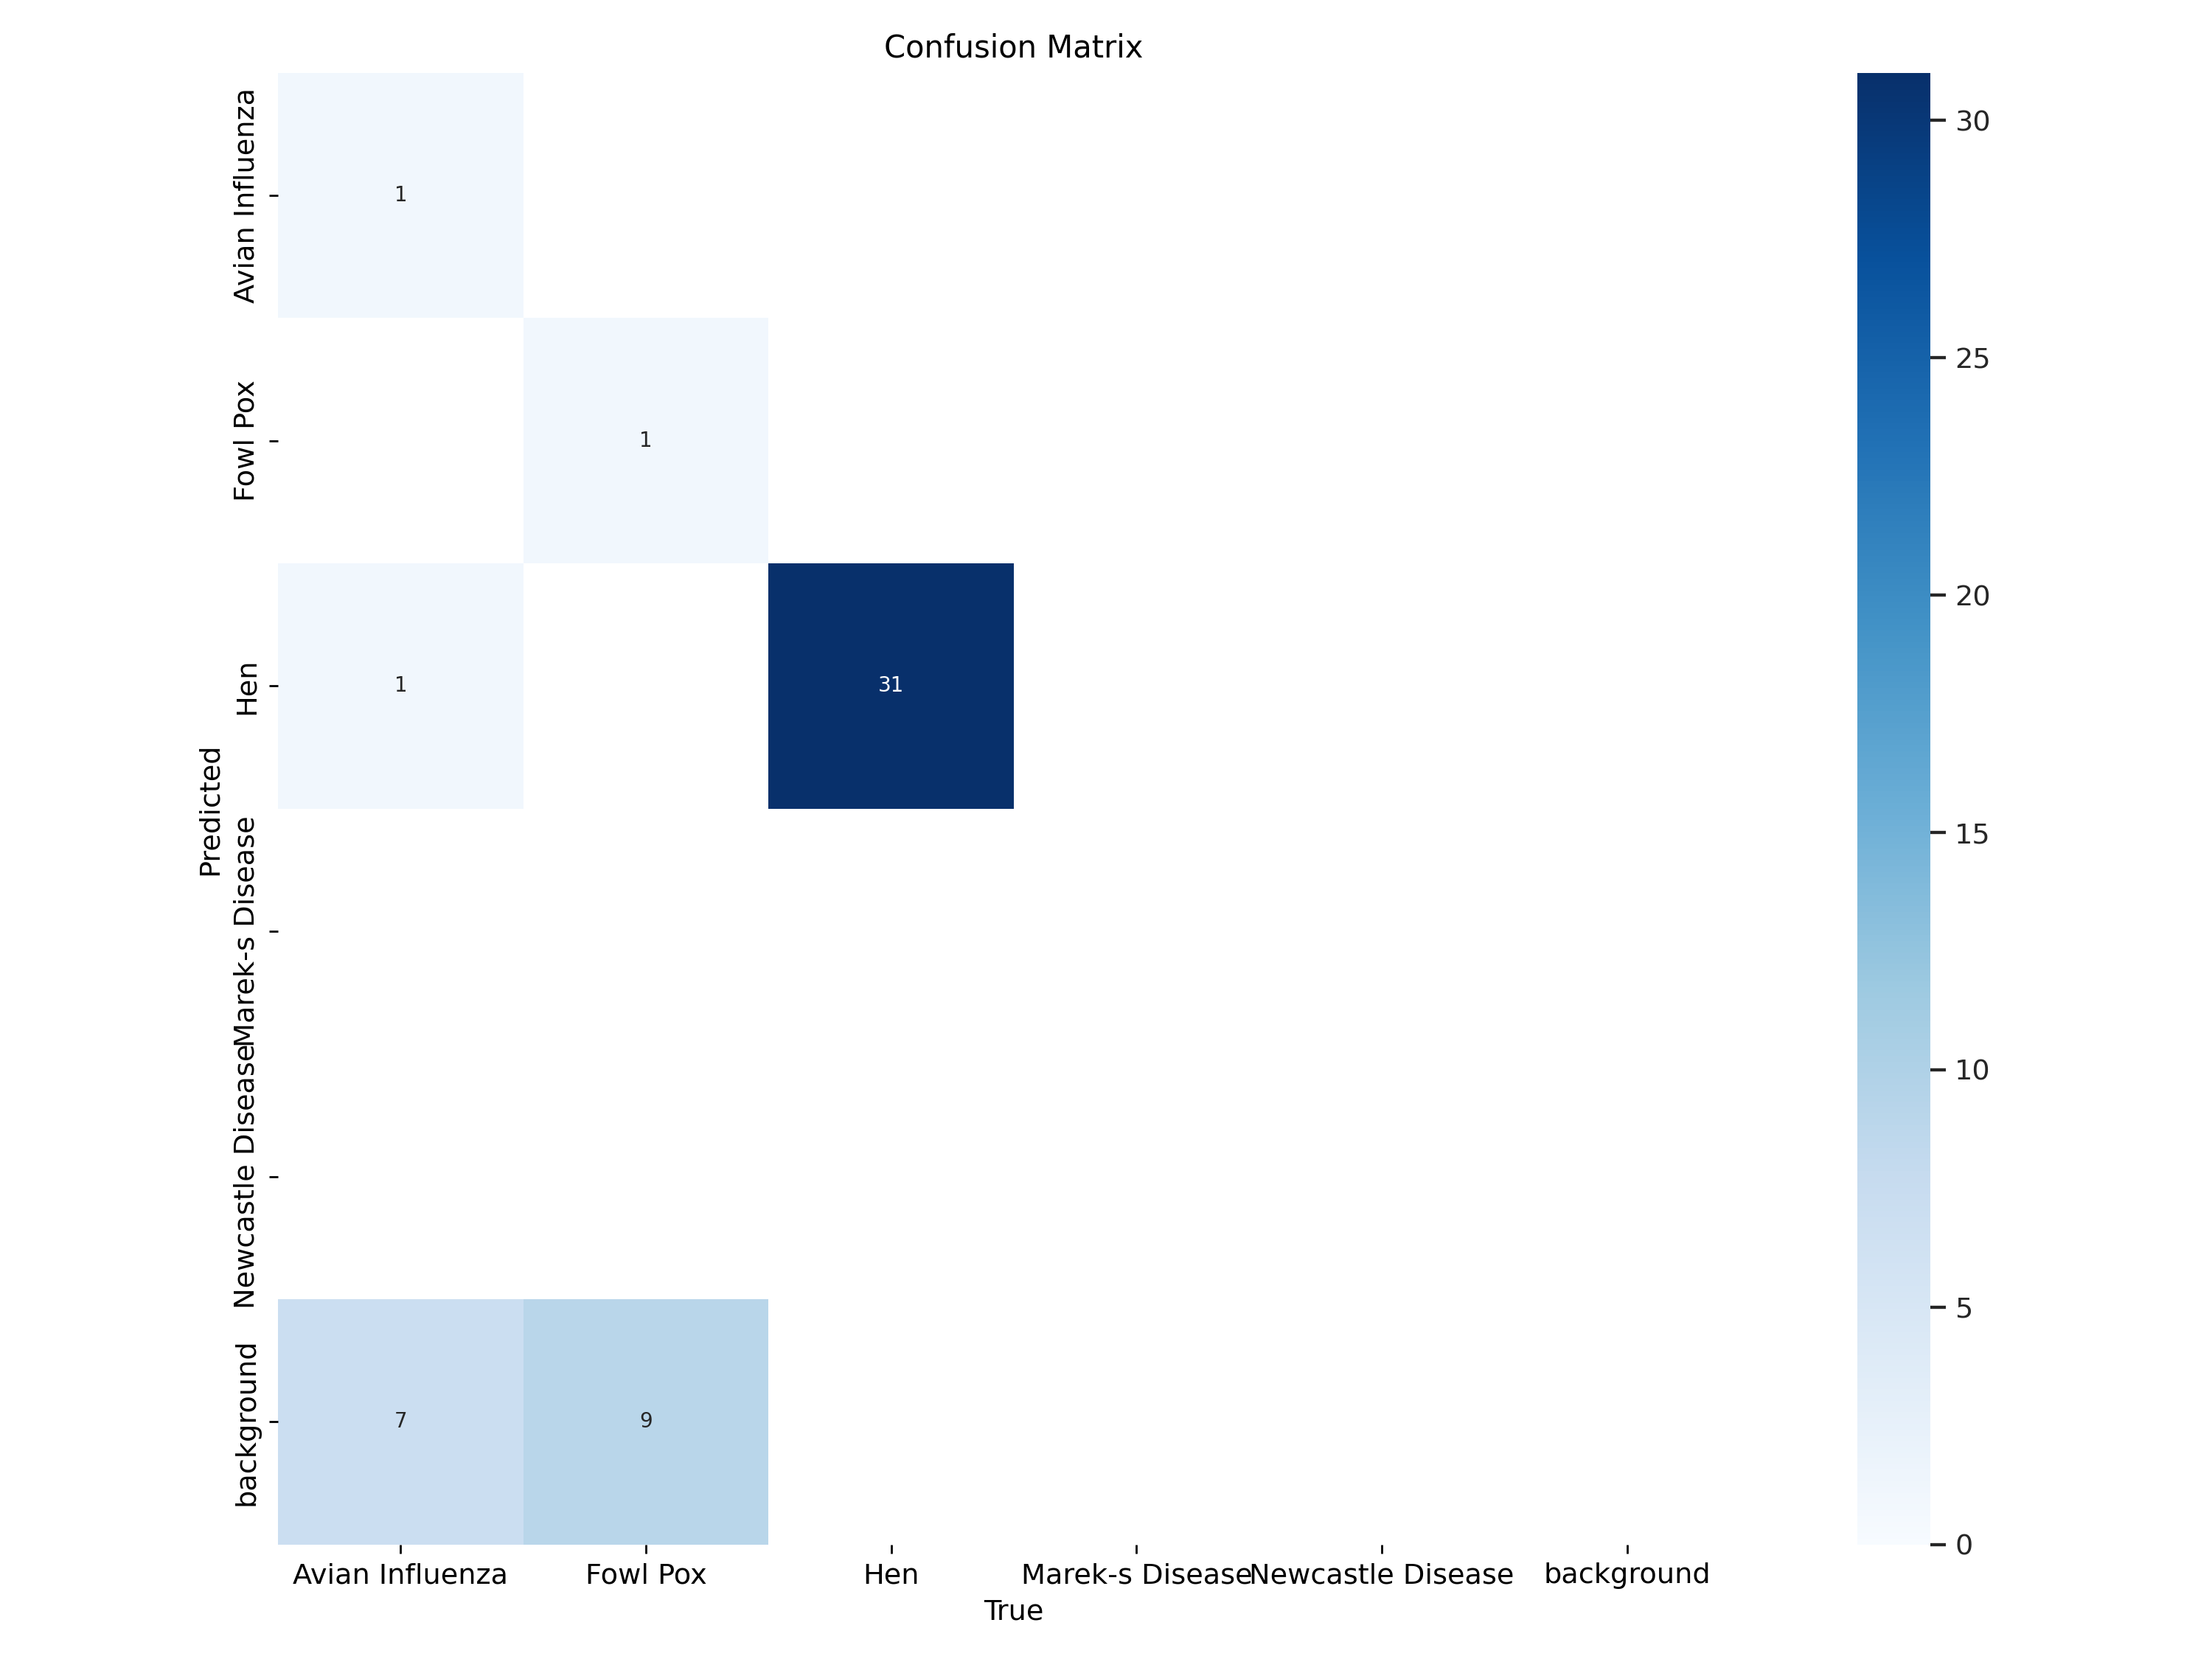

In [26]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train3/confusion_matrix.png', width=600)

/content


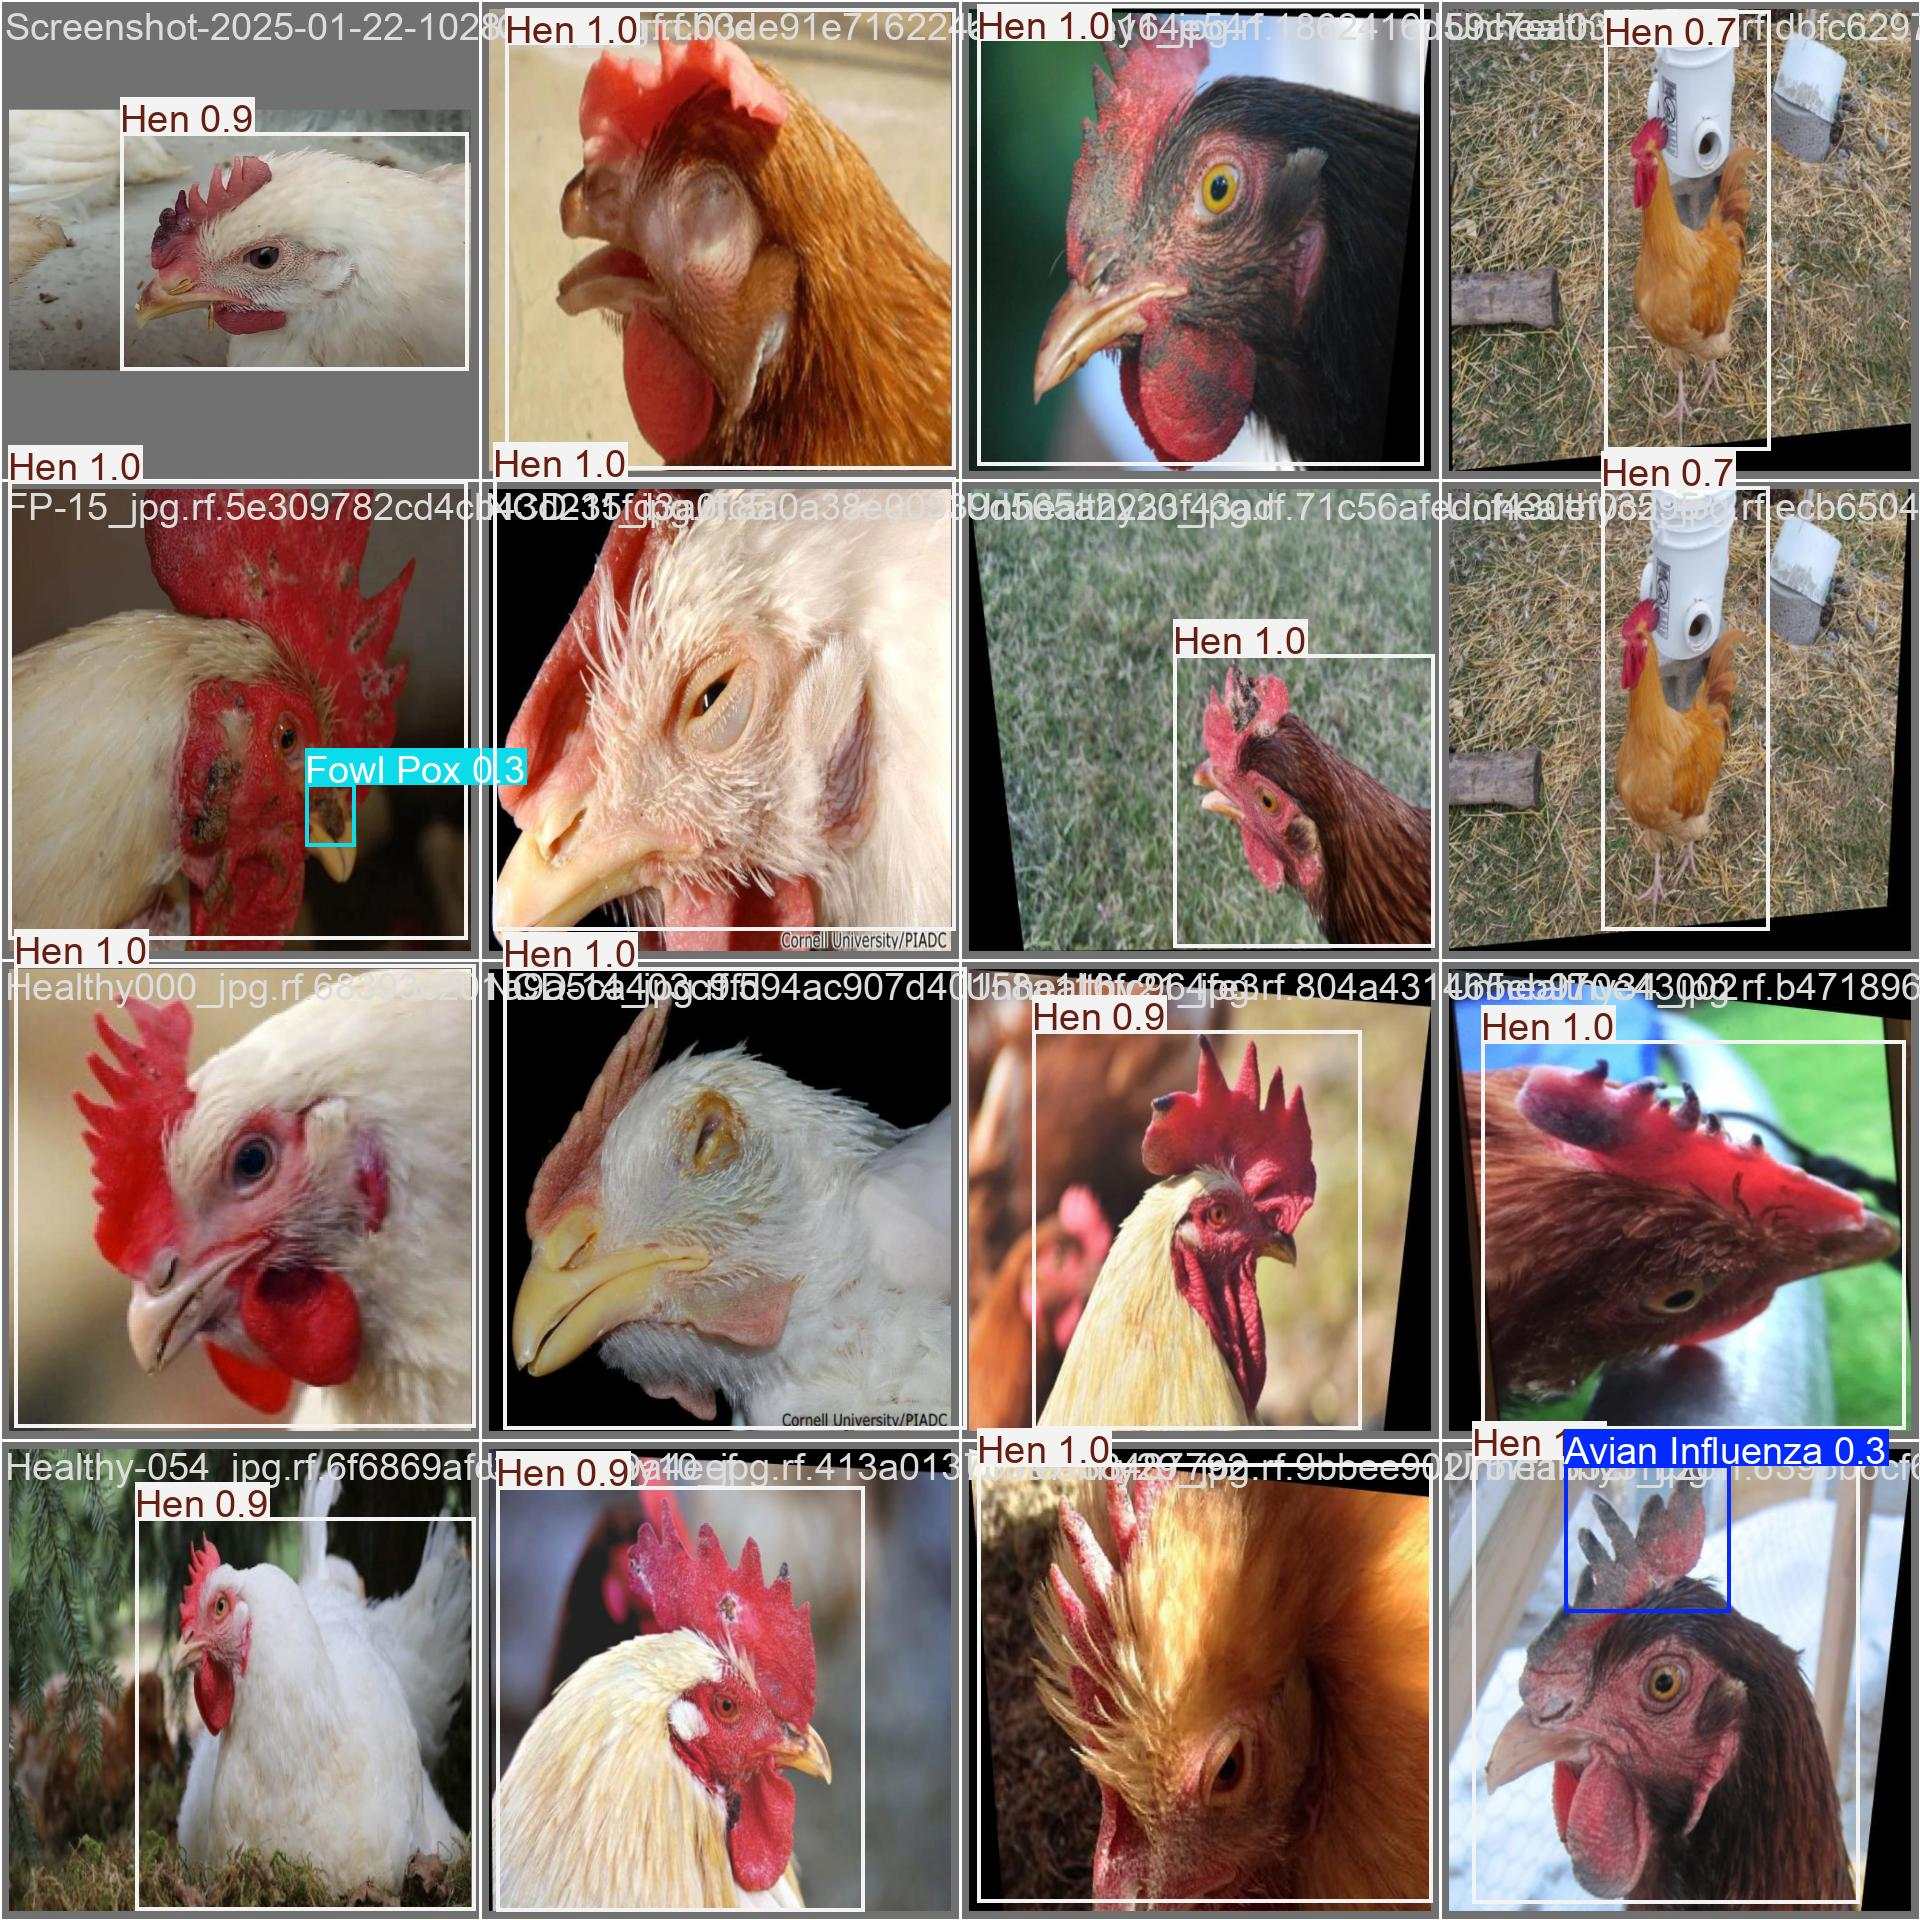

In [25]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train3/val_batch0_pred.jpg', width=600)

## Validate Custom Model

In [27]:
%cd {HOME}
!yolo task=detect mode=val model={HOME}/runs/detect/train3/weights/best.pt data={dataset.location}/data.yaml

/content
Ultralytics YOLOv8.2.103 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 168 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs
val: Scanning /content/datasets/Disease-Prediction-2/valid/labels.cache... 40 images, 0 backgrounds, 0 corrupt: 100% 40/40 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 3/3 [00:02<00:00,  1.26it/s]
                   all         40        265     0.0676      0.173     0.0505     0.0159
       Avian Influenza         40        205     0.0663      0.312     0.0637     0.0168
              Fowl Pox         28         60      0.069     0.0333     0.0373     0.0149
Speed: 12.7ms preprocess, 21.4ms inference, 0.0ms loss, 5.5ms postprocess per image
Results saved to runs/detect/val2
💡 Learn more at https://docs.ultralytics.com/modes/val


## Inference with Custom Model

In [28]:
%cd {HOME}
!yolo task=detect mode=predict model={HOME}/runs/detect/train3/weights/best.pt conf=0.60 source={dataset.location}/test/images save=True

/content
Ultralytics YOLOv8.2.103 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 168 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs

image 1/20 /content/datasets/Disease-Prediction-2/test/images/0010_jpg.rf.f88f45f64698545b7b0de9f3d86c8cfd.jpg: 800x800 (no detections), 22.8ms
image 2/20 /content/datasets/Disease-Prediction-2/test/images/0018-2-_jpg.rf.5a1b8d0c80db5883c677b0de65d90971.jpg: 800x800 1 Hen, 22.8ms
image 3/20 /content/datasets/Disease-Prediction-2/test/images/0029-2-_jpg.rf.131d5c78d2cd2c5f9c73512b30aff5ef.jpg: 800x800 1 Hen, 22.9ms
image 4/20 /content/datasets/Disease-Prediction-2/test/images/0031-2-_jpg.rf.1425197455d319bf5f4231b8029c3092.jpg: 800x800 1 Hen, 22.8ms
image 5/20 /content/datasets/Disease-Prediction-2/test/images/0035_jpg.rf.c0235edc3c33a59d30a5f54a044dca6d.jpg: 800x800 (no detections), 22.9ms
image 6/20 /content/datasets/Disease-Prediction-2/test/images/0038_jpg.rf.8957ae8b881c210602b4cf24b9b2ea97.jpg: 800x800 